<a href="https://colab.research.google.com/github/capybara-dance/dance/blob/main/0317_coveredcall_yfinance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def get_stock_price(ticker, interval="1d"):
    try:
        stock = yf.Ticker(ticker)
        data = stock.history(period="1y", interval=interval)  # Get data for the last 1 year
        if data.empty:
            return None
        return data
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

# Example usage:
ticker_symbol = "441680.KS"  # Ticker symbol for Samsung Electronics on the Korea Exchange
price_data = get_stock_price(ticker_symbol)

if price_data is not None:
    print(price_data)
else:
    print(f"Could not retrieve the price for {ticker_symbol}.")

                                   Open          High           Low  \
Date                                                                  
2025-03-17 00:00:00+09:00   9442.644847   9442.644847   9385.040726   
2025-03-18 00:00:00+09:00   9486.955607   9522.404297   9429.351486   
2025-03-19 00:00:00+09:00   9385.041410   9424.921189   9371.748150   
2025-03-20 00:00:00+09:00   9544.559940   9628.750580   9513.542336   
2025-03-21 00:00:00+09:00   9571.146511   9619.888461   9535.697820   
...                                 ...           ...           ...   
2026-03-11 00:00:00+09:00  11130.000000  11155.000000  11110.000000   
2026-03-12 00:00:00+09:00  11180.000000  11200.000000  11140.000000   
2026-03-13 00:00:00+09:00  11170.000000  11190.000000  11140.000000   
2026-03-16 00:00:00+09:00  11205.000000  11220.000000  11185.000000   
2026-03-17 00:00:00+09:00  11265.000000  11285.000000  11245.000000   

                                  Close  Volume  Dividends  Stock Splits  \


In [ ]:
kodex200wcc = get_stock_price('498400.ks')
kodex200tr = get_stock_price('278530.ks')

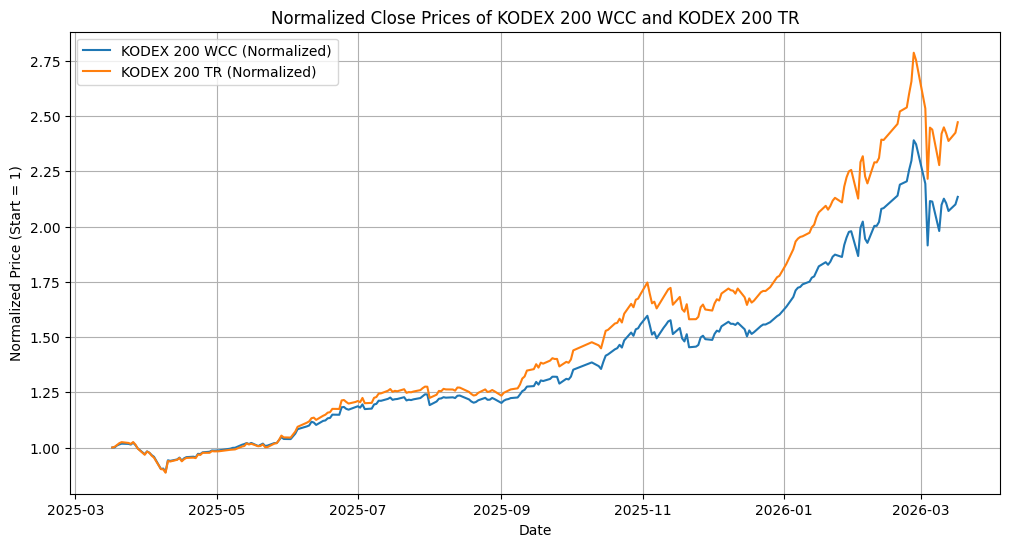

In [ ]:
kodex200wcc_normalized = kodex200wcc['Close'] / kodex200wcc['Close'].iloc[0]
kodex200tr_normalized = kodex200tr['Close'] / kodex200tr['Close'].iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(kodex200wcc_normalized, label='KODEX 200 WCC (Normalized)')
plt.plot(kodex200tr_normalized, label='KODEX 200 TR (Normalized)')
plt.title('Normalized Close Prices of KODEX 200 WCC and KODEX 200 TR')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Start = 1)')
plt.legend()
plt.grid(True)
plt.show()

코드는 초기 투자액, 월별 인출, 배당금 재투자 로직을 기반으로 단일 ETF에 대한 금융 시뮬레이션을 수행하는 `simulate_single_etf_investment` 함수를 정의합니다.

### `simulate_single_etf_investment` 함수 세부 정보:

*   **입력값**:
    *   `df_etf`: ETF의 과거 가격 데이터(반드시 'Close' 및 'Dividends' 열 포함)가 포함된 pandas DataFrame.
    *   `initial_investment`: ETF에 초기 투자된 금액.
    *   `monthly_withdrawal`: 매월 말에 인출할 금액.
    *   `etf_name`: ETF의 식별자 문자열(경고 메시지에 사용).

*   **로직**:
    1.  **초기 투자**: 첫날 종가를 기준으로 구매한 초기 주식 수를 계산합니다.
    2.  **일별 반복**: 과거 데이터의 각 날짜를 반복합니다.
    3.  **배당금 재투자**: 특정 날짜에 배당금이 지급되면, 현재 종가로 배당금액으로 구매할 수 있는 주식 수를 계산하여 기존 주식에 추가합니다.
    4.  **월별 인출**: 매월 말에 지정된 `monthly_withdrawal` 금액이 `portfolio_cash`에서 차감됩니다. 현금이 부족하면 부족액을 충당하기 위해 현재 종가로 주식을 매도합니다. 부족액을 충당할 주식이 충분하지 않으면 경고가 출력됩니다.
    5.  **일별 포트폴리오 가치 계산**: 매일 총 포트폴리오 가치(현재 현금 + ETF 주식 가치)를 계산합니다.

*   **출력값**:
    *   일별 총 포트폴리오 가치를 나타내는 pandas Series.
    *   마지막 날 포트폴리오의 최종 평가액.
    *   시뮬레이션 기간 동안 총 인출된 현금.

### 시뮬레이션 매개변수:

*   `initial_investment_amount`: 각 ETF에 대해 10,000,000 KRW로 설정됩니다.
*   `monthly_withdrawal_amount`: 120,000 KRW로 설정됩니다.

### 실행 및 결과:

`simulate_single_etf_investment` 함수는 지정된 매개변수를 사용하여 `kodex200wcc` 및 `kodex200tr` 모두에 대해 호출되었습니다. 최종 평가액, 총 인출 현금 및 그 합계를 포함한 결과는 각 ETF에 대해 출력되었습니다. 마지막으로, KODEX 200 WCC와 KODEX 200 TR의 일별 총 포트폴리오 가치를 시각적으로 비교하는 차트가 생성되었습니다.

Warning [KODEX 200 WCC]: Still negative cash after selling all available shares on 2025-08-29. Deficit: -0.00 KRW
Warning [KODEX 200 WCC]: Still negative cash after selling all available shares on 2025-11-28. Deficit: -0.00 KRW
Warning [KODEX 200 TR]: Still negative cash after selling all available shares on 2025-11-28. Deficit: -0.00 KRW
--- KODEX 200 WCC Simulation Results ---
Final Appraisal Amount: 22,953,952.51 KRW
Total Withdrawn Cash: 1,560,000.00 KRW
Sum (Final Appraisal + Total Withdrawn): 24,513,952.51 KRW

--- KODEX 200 TR Simulation Results ---
Final Appraisal Amount: 22,014,263.96 KRW
Total Withdrawn Cash: 1,560,000.00 KRW
Sum (Final Appraisal + Total Withdrawn): 23,574,263.96 KRW



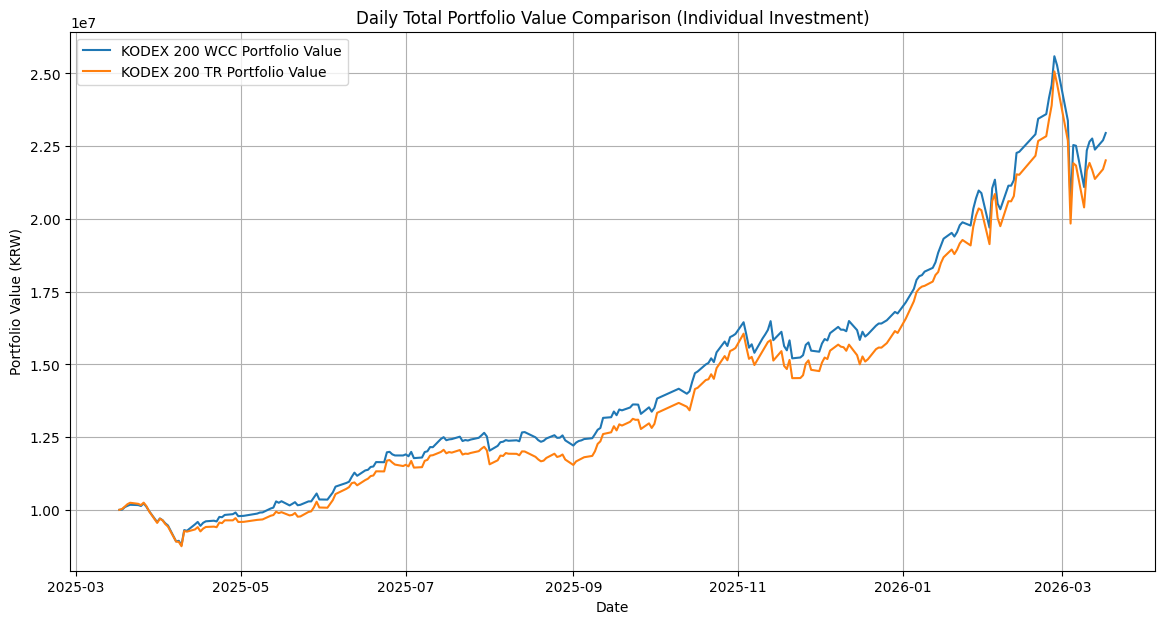

In [31]:
import pandas as pd

def simulate_single_etf_investment(df_etf, initial_investment, monthly_withdrawal, etf_name):
    dates = df_etf.index.normalize() # Normalize to remove time component for easier comparison

    portfolio_cash = 0
    etf_shares = 0
    total_withdrawn_cash = 0
    daily_portfolio_values = []

    # Initial Investment
    first_date = dates[0]
    initial_etf_price = df_etf.loc[first_date, 'Close']
    etf_shares = initial_investment / initial_etf_price

    # Use a set to track which months have already had a withdrawal
    withdrawn_months = set()

    for i, date in enumerate(dates):
        current_etf_price = df_etf.loc[date, 'Close']

        # 1. Handle Dividends (Reinvest)
        etf_dividend = df_etf.loc[date, 'Dividends'] if 'Dividends' in df_etf.columns else 0
        if etf_dividend > 0:
            dividend_amount_etf = etf_shares * etf_dividend
            shares_bought_etf = dividend_amount_etf / current_etf_price
            etf_shares += shares_bought_etf

        # 2. Handle Monthly Withdrawal at the last trading day of the month
        # Determine if 'date' is the last trading day for its month in the 'dates' list
        is_last_trading_day_of_current_month = False
        if i == len(dates) - 1: # If it's the very last date in the loop
            is_last_trading_day_of_current_month = True
        elif date.month != dates[i+1].month: # If the month changes for the next trading day
            is_last_trading_day_of_current_month = True

        current_month_key = (date.year, date.month)

        if is_last_trading_day_of_current_month and current_month_key not in withdrawn_months:
            portfolio_cash -= monthly_withdrawal
            total_withdrawn_cash += monthly_withdrawal
            withdrawn_months.add(current_month_key)

            if portfolio_cash < 0:
                deficit = -portfolio_cash
                etf_value = etf_shares * current_etf_price

                if etf_value > 0:
                    shares_to_sell_etf = min(deficit / current_etf_price, etf_shares)
                    actual_sell_amount_etf = shares_to_sell_etf * current_etf_price
                    etf_shares -= shares_to_sell_etf
                    portfolio_cash += actual_sell_amount_etf

                    if portfolio_cash < 0:
                        # Portfolio fully depleted: correct the overcount and clamp cash to 0
                        total_withdrawn_cash += portfolio_cash  # portfolio_cash is negative, reduces total
                        portfolio_cash = 0
                        print(f"Warning [{etf_name}]: Portfolio fully depleted on {date.strftime('%Y-%m-%d')}. Only partial withdrawal was possible.")
                else:
                    # No shares left at all
                    total_withdrawn_cash += portfolio_cash  # correct overcount
                    portfolio_cash = 0
                    print(f"Warning [{etf_name}]: No stock value to sell to cover deficit on {date.strftime('%Y-%m-%d')}. Cash: {portfolio_cash:,.2f} KRW")

        # 3. Calculate Daily Portfolio Value
        current_etf_value = etf_shares * current_etf_price
        total_portfolio_value_today = portfolio_cash + current_etf_value
        daily_portfolio_values.append(total_portfolio_value_today)

    daily_portfolio_series = pd.Series(daily_portfolio_values, index=dates)
    final_appraisal_amount = daily_portfolio_values[-1] if daily_portfolio_values else 0

    return daily_portfolio_series, final_appraisal_amount, total_withdrawn_cash

# Parameters for the simulation
initial_investment_amount = 10_000_000 # 10 million KRW for each
monthly_withdrawal_amount = 120_000 # 120,000 KRW

# Run simulation for KODEX 200 WCC
daily_portfolio_wcc, final_appraisal_wcc, total_withdrawn_wcc = simulate_single_etf_investment(kodex200wcc, initial_investment_amount, monthly_withdrawal_amount, 'KODEX 200 WCC')

# Run simulation for KODEX 200 TR
daily_portfolio_tr, final_appraisal_tr, total_withdrawn_tr = simulate_single_etf_investment(kodex200tr, initial_investment_amount, monthly_withdrawal_amount, 'KODEX 200 TR')

print("--- KODEX 200 WCC Simulation Results ---")
print(f"Final Appraisal Amount: {final_appraisal_wcc:,.2f} KRW")
print(f"Total Withdrawn Cash: {total_withdrawn_wcc:,.2f} KRW")
print(f"Sum (Final Appraisal + Total Withdrawn): {final_appraisal_wcc + total_withdrawn_wcc:,.2f} KRW\n")

print("--- KODEX 200 TR Simulation Results ---")
print(f"Final Appraisal Amount: {final_appraisal_tr:,.2f} KRW")
print(f"Total Withdrawn Cash: {total_withdrawn_tr:,.2f} KRW")
print(f"Sum (Final Appraisal + Total Withdrawn): {final_appraisal_tr + total_withdrawn_tr:,.2f} KRW\n")

# Plot daily portfolio values for comparison
plt.figure(figsize=(14, 7))
plt.plot(daily_portfolio_wcc, label='KODEX 200 WCC Portfolio Value')
plt.plot(daily_portfolio_tr, label='KODEX 200 TR Portfolio Value')
plt.title('Daily Total Portfolio Value Comparison (Individual Investment)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value (KRW)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Sub-period Analysis: 시장 국면별 시뮬레이션 비교

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── 1. 시장 국면(Regime) 자동 감지 ────────────────────────────────────────────
# TR ETF를 시장 벤치마크로 사용 (배당 내부 재투자 → 순수 주가 수익률 반영)
tr_close  = kodex200tr['Close'].copy()
wcc_close = kodex200wcc['Close'].copy()

# 공통 날짜만 사용
common_dates = tr_close.index.intersection(wcc_close.index)
tr_close  = tr_close.loc[common_dates]
wcc_close = wcc_close.loc[common_dates]
N = len(common_dates)

# 20일 롤링 수익률로 국면 판단
WINDOW = 20
tr_roll = tr_close.pct_change(WINDOW).fillna(0)

SHARP_RISE_THRESH  =  0.04   # 20일간 +4% 이상 → 급격한 상승
DECLINE_THRESH     = -0.03   # 20일간 -3% 이하 → 하락

def classify(r):
    if r > SHARP_RISE_THRESH:
        return '상승'
    elif r < DECLINE_THRESH:
        return '하락'
    else:
        return '횡보'

regime_labels = tr_roll.map(classify)

# 연속 구간 합치기 (최소 10거래일 이상인 블록만 인정)
blocks = []
cur_label = regime_labels.iloc[0]
cur_start = 0
for i in range(1, N):
    if regime_labels.iloc[i] != cur_label:
        blocks.append((cur_label, cur_start, i - 1))
        cur_label = regime_labels.iloc[i]
        cur_start = i
blocks.append((cur_label, cur_start, N - 1))

MIN_DAYS = 10
merged_blocks = []
for label, start, end in blocks:
    if (end - start + 1) < MIN_DAYS and merged_blocks:
        # 직전 블록에 흡수
        prev_label, prev_start, _ = merged_blocks[-1]
        merged_blocks[-1] = (prev_label, prev_start, end)
    else:
        merged_blocks.append((label, start, end))

print("감지된 시장 국면:")
for label, start, end in merged_blocks:
    n_days = end - start + 1
    tr_ret = (tr_close.iloc[end] / tr_close.iloc[start] - 1) * 100
    print(f"  [{label}] {common_dates[start].date()} ~ {common_dates[end].date()} "
          f"({n_days}거래일) | TR 수익률: {tr_ret:+.1f}%")

# ─── 2. 구간별 시뮬레이션 실행 ──────────────────────────────────────────────────
initial_investment = 10_000_000
monthly_withdrawal = 120_000

def run_phase_simulation(df_wcc_sub, df_tr_sub, label):
    """Sub-period simulation and return result dict."""
    _, f_wcc, w_wcc = simulate_single_etf_investment(df_wcc_sub, initial_investment, monthly_withdrawal, 'WCC')
    _, f_tr,  w_tr  = simulate_single_etf_investment(df_tr_sub,  initial_investment, monthly_withdrawal, 'TR')
    
    tr_pct  = (df_tr_sub['Close'].iloc[-1]  / df_tr_sub['Close'].iloc[0]  - 1) * 100
    wcc_pct = (df_wcc_sub['Close'].iloc[-1] / df_wcc_sub['Close'].iloc[0] - 1) * 100
    
    return {
        'label': label,
        'start': df_tr_sub.index[0].date(),
        'end':   df_tr_sub.index[-1].date(),
        'n_days': len(df_tr_sub),
        'tr_price_ret':  tr_pct,
        'wcc_price_ret': wcc_pct,
        'wcc_final': f_wcc, 'wcc_withdrawn': w_wcc, 'wcc_sum': f_wcc + w_wcc,
        'tr_final':  f_tr,  'tr_withdrawn':  w_tr,  'tr_sum':  f_tr  + w_tr,
        'wcc_ret': (f_wcc + w_wcc) / initial_investment * 100 - 100,
        'tr_ret':  (f_tr  + w_tr)  / initial_investment * 100 - 100,
    }

results = []
for label, start, end in merged_blocks:
    df_wcc_sub = kodex200wcc.iloc[start:end+1].copy()
    df_tr_sub  = kodex200tr.iloc[start:end+1].copy()
    r = run_phase_simulation(df_wcc_sub, df_tr_sub, label)
    results.append(r)

# ─── 3. 결과 출력 ───────────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print(f"{'구간':^8} | {'기간':^22} | {'TR가격':>8} | {'WCC합계수익률':>12} | {'TR합계수익률':>12} | {'우세':>5}")
print("-" * 72)
for r in results:
    winner = 'WCC' if r['wcc_sum'] > r['tr_sum'] else 'TR '
    print(f"{r['label']:^8} | {str(r['start']):>11} ~ {str(r['end']):>11} | "
          f"{r['tr_price_ret']:>+7.1f}% | {r['wcc_ret']:>+11.1f}% | {r['tr_ret']:>+11.1f}% | {winner}")
print("=" * 72)

# ─── 4. 시각화 ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ─── 차트 1: 정규화 가격 + 국면 배경색 ────────────────────────────────────────
ax1 = axes[0]
wcc_norm = wcc_close / wcc_close.iloc[0]
tr_norm  = tr_close  / tr_close.iloc[0]

colors = {'상승': '#ffe0e0', '하락': '#e0e0ff', '횡보': '#e8ffe0'}
for label, start, end in merged_blocks:
    ax1.axvspan(common_dates[start], common_dates[end],
                alpha=0.35, color=colors.get(label, '#f0f0f0'), label=f'_{label}')

ax1.plot(common_dates, tr_norm,  label='KODEX 200 TR',  color='royalblue', linewidth=1.8)
ax1.plot(common_dates, wcc_norm, label='KODEX 200 WCC', color='darkorange', linewidth=1.8)

# 국면 레이블 텍스트
for label, start, end in merged_blocks:
    mid = (start + end) // 2
    ax1.text(common_dates[mid], ax1.get_ylim()[0] if ax1.get_ylim()[0] > 0 else 0.05,
             label, ha='center', fontsize=9, color='gray', va='bottom')

ax1.set_title('KODEX 200 TR vs WCC — 정규화 종가 및 시장 국면', fontsize=13)
ax1.set_xlabel('날짜')
ax1.set_ylabel('정규화 가격 (시작=1.0)')
legend_patches = [
    mpatches.Patch(color=colors['상승'], alpha=0.6, label='급격한 상승 국면'),
    mpatches.Patch(color=colors['하락'], alpha=0.6, label='하락/조정 국면'),
    mpatches.Patch(color=colors['횡보'], alpha=0.6, label='횡보 국면'),
]
ax1.legend(handles=legend_patches + ax1.lines[:2], loc='upper left')
ax1.grid(True, alpha=0.3)

# ─── 차트 2: 국면별 WCC vs TR 합계 수익률 막대 ────────────────────────────────
ax2 = axes[1]
x = np.arange(len(results))
width = 0.35
wcc_rets = [r['wcc_ret'] for r in results]
tr_rets  = [r['tr_ret']  for r in results]
labels   = [f"{r['label']}\n({r['n_days']}거래일)" for r in results]

bars_wcc = ax2.bar(x - width/2, wcc_rets, width, label='KODEX 200 WCC', color='darkorange', alpha=0.85)
bars_tr  = ax2.bar(x + width/2, tr_rets,  width, label='KODEX 200 TR',  color='royalblue',  alpha=0.85)

for bar in bars_wcc:
    h = bar.get_height()
    ax2.annotate(f'{h:+.1f}%', xy=(bar.get_x()+bar.get_width()/2, h),
                 xytext=(0, 3 if h >= 0 else -12), textcoords='offset points',
                 ha='center', fontsize=9, color='darkorange')
for bar in bars_tr:
    h = bar.get_height()
    ax2.annotate(f'{h:+.1f}%', xy=(bar.get_x()+bar.get_width()/2, h),
                 xytext=(0, 3 if h >= 0 else -12), textcoords='offset points',
                 ha='center', fontsize=9, color='royalblue')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('시장 국면별 합계 수익률 비교 (최종 평가액 + 총 인출액)', fontsize=13)
ax2.set_ylabel('합계 수익률 (%)')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
